In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import sklearn
import sys
import matplotlib
import platform

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)
print("Sklearn version:", sklearn.__version__)
print("Python path:", sys.executable)
print("Python version:", platform.python_version())

NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Sklearn version: 1.6.1
Python path: /usr/bin/python3
Python version: 3.12.12


In [4]:
df = pd.read_csv('/content/telco_customer_data_v2.csv')

In [5]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,CUST00003,Female,No,No,No,42.0,Yes,Yes,DSL,No,...,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Yes,NaN,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes


In [6]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
66766,CUST66767,Female,0,Yes,No,1.0,Yes,Yes,Fiber optic,Yes,...,No,Yes,Yes,No,One year,Yes,Mailed check,31.00,31.0,No
66767,CUST66768,Female,0,No,No,13.0,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Two year,Yes,Electronic check,52.98,688.74,Yes
66768,CUST66769,Male,0,Yes,No,48.0,Yes,No,Fiber optic,Yes,...,No,No internet service,No,Yes,Month-to-month,No,Bank transfer (automatic),96.89,4650.72,Yes
66769,CUST66770,Female,0,No,No,32.0,Yes,Yes,DSL,NaN,...,No internet service,No,No,No internet service,Month-to-month,No,Electronic check,38.69,1238.08,No
66770,CUST66771,Male,0,No,No,4.0,Yes,N,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66771 entries, 0 to 66770
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        66771 non-null  object 
 1   gender            66046 non-null  object 
 2   SeniorCitizen     66142 non-null  object 
 3   Partner           63406 non-null  object 
 4   Dependents        63405 non-null  object 
 5   tenure            66226 non-null  float64
 6   PhoneService      66771 non-null  object 
 7   MultipleLines     64993 non-null  object 
 8   InternetService   66770 non-null  object 
 9   OnlineSecurity    63989 non-null  object 
 10  OnlineBackup      64150 non-null  object 
 11  DeviceProtection  63999 non-null  object 
 12  TechSupport       64151 non-null  object 
 13  StreamingTV       64059 non-null  object 
 14  StreamingMovies   64117 non-null  object 
 15  Contract          66770 non-null  object 
 16  PaperlessBilling  66770 non-null  object

In [9]:
df.describe()

,tenure,MonthlyCharges
count,66226.000000,66399.000000
mean,30.569731,60.606724
std,90.232387,111.689878
min,-10.000000,18.000000
25%,10.000000,29.675000
50%,20.000000,41.190000
75%,34.000000,63.870000
max,999.000000,1499.770000


In [10]:
df.shape

(66771, 21)

In [11]:
df.isnull().sum()

,0
customerID,0
gender,725
SeniorCitizen,629
Partner,3365
Dependents,3366
tenure,545
PhoneService,0
MultipleLines,1778
InternetService,1
OnlineSecurity,2782


In [12]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [13]:
df['SeniorCitizen'] = df['SeniorCitizen'].fillna(df['SeniorCitizen'].mode()[0])

In [14]:
df['Partner'] = df['Partner'].fillna(df['Partner'].mode()[0])

In [15]:
for col in df:
  if df[col].dtype == 'object':
    df[col] = df[col].fillna(df[col].mode()[0])
  else:
    df[col] = df[col].fillna(df[col].mean())

In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
print(df.duplicated().sum())

0


In [18]:
for col in df:
  if df[col].dtype == 'object':
    print(col,df[col].unique())

customerID ['CUST00001' 'CUST00002' 'CUST00003' ... 'CUST66769' 'CUST66770'
 'CUST66771']
gender ['Male' 'Female' 'f' 'Man' 'FEMALE' 'm' 'male']
SeniorCitizen ['0' '1' 'No' 'Yes' 'not senior']
Partner ['No' 'Yes']
Dependents ['Yes' 'No']
PhoneService ['Yes' 'No']
MultipleLines ['Yes' 'No' 'No phone service' 'N']
InternetService ['No' 'DSL' 'Fiber optic']
OnlineSecurity ['No internet service' 'No' 'Yes' 'Y' 'True']
OnlineBackup ['No internet service' 'No' 'Yes' 'Y' 'True']
DeviceProtection ['No internet service' 'No' 'Yes' 'Y' 'True']
TechSupport ['No internet service' 'Yes' 'No' 'Y' 'True']
StreamingTV ['No internet service' 'No' 'Yes' 'Y' 'True']
StreamingMovies ['No internet service' 'No' 'Yes' 'Y' 'True']
Contract ['Month-to-month' 'One year' 'Two year' 'M-M']
PaperlessBilling ['No' 'Yes']
PaymentMethod ['Mailed check' 'Bank transfer (automatic)' 'Electronic check'
 'Credit card (automatic)' 'BANK TRANSFER']
TotalCharges ['205.83' '46.3' '1790.46' ... '325.02' '4650.72' '1238.08']
C

In [19]:
df['gender'].unique()

array(['Male', 'Female', 'f', 'Man', 'FEMALE', 'm', 'male'], dtype=object)

In [20]:
df['gender'] = df['gender'].str.strip().str.lower()

df['gender'] = df['gender'].replace({
    'male': 'm',
    'man': 'm',
    'female': 'f'
})


In [21]:
df['gender'].value_counts()

,count
gender,
f,33944
m,32827


In [22]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({'0':'No','1':'Yes','not senior':'No'})

In [23]:
df['PhoneService'] = df['PhoneService'].replace({'No phone service':'No'})

In [24]:
df['OnlineSecurity'] = df['OnlineSecurity'].replace({'Y':'Yes','True':'Yes'})

In [25]:
df['OnlineBackup'] = df['OnlineBackup'].replace({'Y':'Yes','True':'Yes'})

In [26]:
df['DeviceProtection'] = df['DeviceProtection'].replace({'Y':'Yes','True':'Yes'})

In [27]:
df['TechSupport'] = df['TechSupport'].replace({'Y':'Yes','True':'Yes'})

In [28]:
df['StreamingTV'] = df['StreamingTV'].replace({'Y':'Yes','True':'Yes'})

In [29]:
df['StreamingMovies'] = df['StreamingMovies'].replace({'Y':'Yes','True':'Yes'})

In [30]:
df['Churn'] = df['Churn'].replace({'Y':'Yes','N':'No','NO CHURN':'No','CHURNED':'Yes','Unknown':'No'})

In [31]:
df['Contract'] = df['Contract'].replace({'M-M':'Month-to-month'})

In [32]:
df['Churn'].value_counts()

,count
Churn,
No,35527
Yes,31244


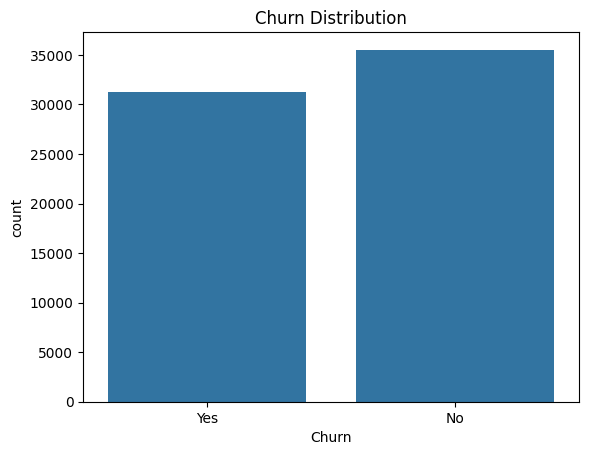

In [33]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

### Insight:
Approximately 27% of customers churned, indicating moderate class imbalance.
This suggests recall should be prioritized during modeling.

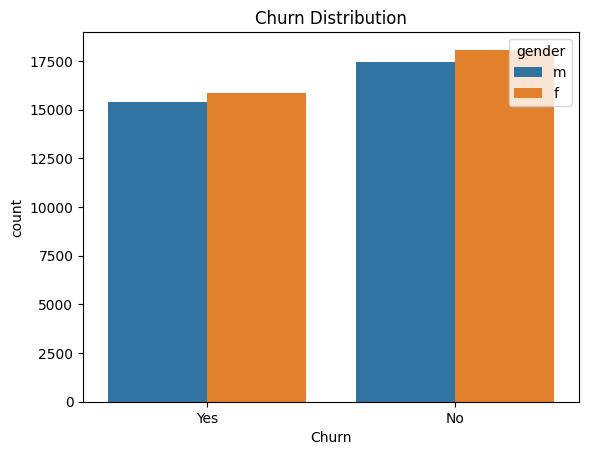

In [34]:
sns.countplot(x='Churn',hue='gender', data=df)
plt.title("Churn Distribution")
plt.show()

In [35]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1 Yr','1-2 Yr','2-4 Yr','4-6 Yr']
)

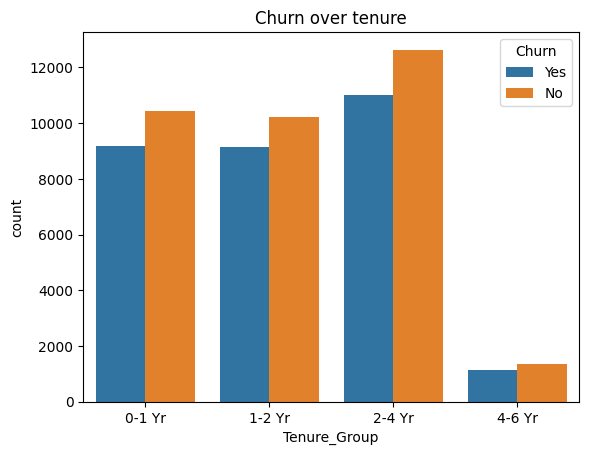

In [36]:
sns.countplot(x='Tenure_Group',hue='Churn',data=df)
plt.title('Churn over tenure')
plt.show()

### Insight:
Customers with lower tenure are more likely to churn, suggesting early lifecycle engagement is critical.

In [37]:
pd.crosstab(df['Tenure_Group'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Tenure_Group,,
0-1 Yr,53.151775,46.848225
1-2 Yr,52.801323,47.198677
2-4 Yr,53.427206,46.572794
4-6 Yr,54.661865,45.338135


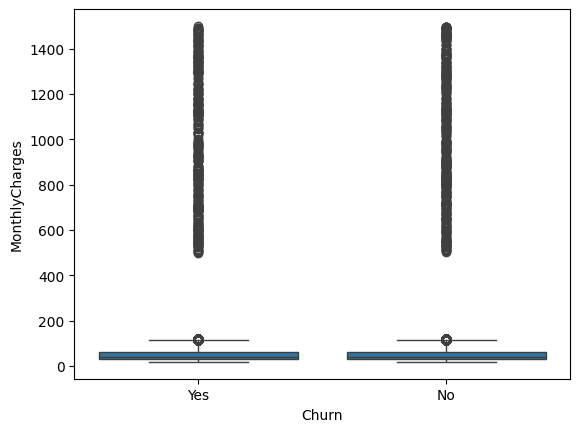

In [38]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [39]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,30.271013,69.728987
One year,80.183609,19.816391
Two year,94.954266,5.045734


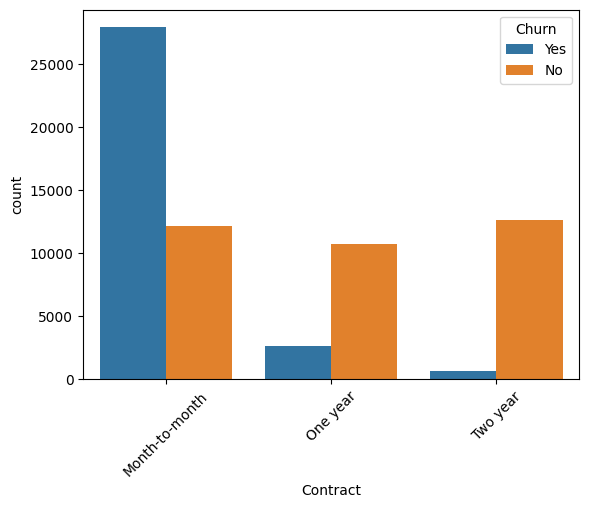

In [40]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

### Insight:
Month-to-month customers show significantly higher churn rate compared to long-term contract customers.
This indicates contract duration is a strong retention factor.

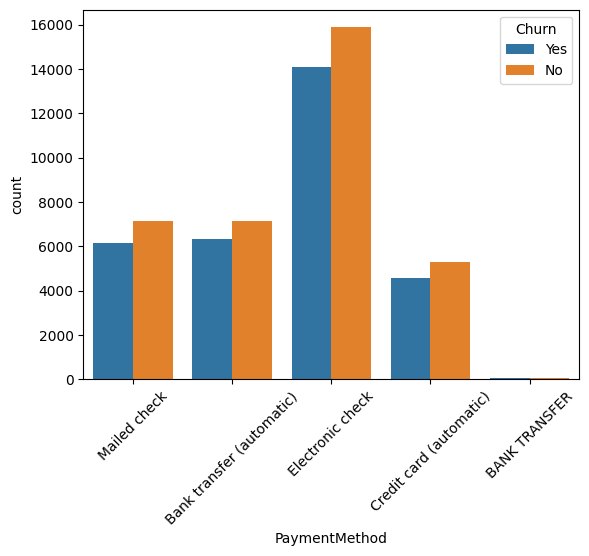

In [41]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

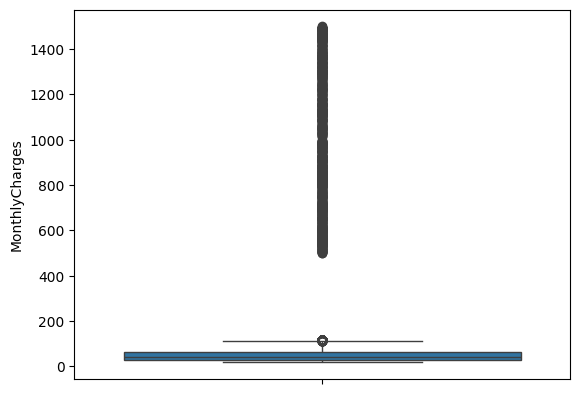

In [42]:
sns.boxplot(y=df['MonthlyCharges'])
plt.show()

####Insight:
This does not means that it has too many outliers, It means monthly charges are large for more service buyer customer.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66771 entries, 0 to 66770
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        66771 non-null  object  
 1   gender            66771 non-null  object  
 2   SeniorCitizen     66771 non-null  object  
 3   Partner           66771 non-null  object  
 4   Dependents        66771 non-null  object  
 5   tenure            66771 non-null  float64 
 6   PhoneService      66771 non-null  object  
 7   MultipleLines     66771 non-null  object  
 8   InternetService   66771 non-null  object  
 9   OnlineSecurity    66771 non-null  object  
 10  OnlineBackup      66771 non-null  object  
 11  DeviceProtection  66771 non-null  object  
 12  TechSupport       66771 non-null  object  
 13  StreamingTV       66771 non-null  object  
 14  StreamingMovies   66771 non-null  object  
 15  Contract          66771 non-null  object  
 16  PaperlessBilling  6677

In [44]:
#customerID not Providing any information about churn prediction
custd_id = df['customerID']
df = df.drop(columns='customerID')

In [45]:
df.shape

(66771, 21)

In [46]:
df['gender']

,gender
0,m
1,m
2,f
3,f
4,m
...,...
66766,f
66767,f
66768,m
66769,f


In [47]:
df['gender'].unique()

array(['m', 'f'], dtype=object)

In [48]:
df['gender'] = df['gender'].map({'m':0,'f':1}).astype(int)

In [49]:
df['gender'].unique()

array([0, 1])

In [50]:
df['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

In [51]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({'No':0,'Yes':1}).astype(int)

In [52]:
df['SeniorCitizen'].unique()

array([0, 1])

In [53]:
df['Partner'].unique()

array(['No', 'Yes'], dtype=object)

In [54]:
df['Partner'] = df['Partner'].map({'No':0,'Yes':1}).astype(int)

In [55]:
df['Partner'].unique()

array([0, 1])

In [56]:
df['Dependents'].unique()

array(['Yes', 'No'], dtype=object)

In [57]:
df['Dependents'] = df['Dependents'].map({'No':0,'Yes':1}).astype(int)

In [58]:
df['Dependents'].unique()

array([1, 0])

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66771 entries, 0 to 66770
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            66771 non-null  int64   
 1   SeniorCitizen     66771 non-null  int64   
 2   Partner           66771 non-null  int64   
 3   Dependents        66771 non-null  int64   
 4   tenure            66771 non-null  float64 
 5   PhoneService      66771 non-null  object  
 6   MultipleLines     66771 non-null  object  
 7   InternetService   66771 non-null  object  
 8   OnlineSecurity    66771 non-null  object  
 9   OnlineBackup      66771 non-null  object  
 10  DeviceProtection  66771 non-null  object  
 11  TechSupport       66771 non-null  object  
 12  StreamingTV       66771 non-null  object  
 13  StreamingMovies   66771 non-null  object  
 14  Contract          66771 non-null  object  
 15  PaperlessBilling  66771 non-null  object  
 16  PaymentMethod     6677

In [60]:
df['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [61]:
df = df.drop(columns='Tenure_Group')

In [62]:
df['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [63]:
df['PhoneService'] = df['PhoneService'].map({'No':0,'Yes':1,'Ye':1}).astype(int)

In [64]:
for col in df:
  if df[col].dtype == 'object':
    print(f"{col} --> ",df[col].unique())

MultipleLines -->  ['Yes' 'No' 'No phone service' 'N']
InternetService -->  ['No' 'DSL' 'Fiber optic']
OnlineSecurity -->  ['No internet service' 'No' 'Yes']
OnlineBackup -->  ['No internet service' 'No' 'Yes']
DeviceProtection -->  ['No internet service' 'No' 'Yes']
TechSupport -->  ['No internet service' 'Yes' 'No']
StreamingTV -->  ['No internet service' 'No' 'Yes']
StreamingMovies -->  ['No internet service' 'No' 'Yes']
Contract -->  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -->  ['No' 'Yes']
PaymentMethod -->  ['Mailed check' 'Bank transfer (automatic)' 'Electronic check'
 'Credit card (automatic)' 'BANK TRANSFER']
TotalCharges -->  ['205.83' '46.3' '1790.46' ... '325.02' '4650.72' '1238.08']
Churn -->  ['Yes' 'No']


In [86]:
df['MultipleLines'] = df['MultipleLines'].map({'Yes':1,'No':0,'No phone service':2,'N':0}).astype(int)

In [66]:
df['InternetService'] = df['InternetService'].map({'DSL':1,'No':0,'Fiber optic':2}).astype(int)

In [67]:
df['OnlineSecurity'] = df['OnlineSecurity'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)

In [68]:
df['OnlineSecurity'].unique()

array([2, 0, 1])

In [69]:
df['OnlineBackup'] = df['OnlineBackup'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)

In [70]:
df['DeviceProtection'] = df['DeviceProtection'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)

In [71]:
for col in df:
  if df[col].dtype == 'object':
    print(f"{col} --> ",df[col].unique())

MultipleLines -->  ['Yes' 'No' 'No phone service' 'N']
TechSupport -->  ['No internet service' 'Yes' 'No']
StreamingTV -->  ['No internet service' 'No' 'Yes']
StreamingMovies -->  ['No internet service' 'No' 'Yes']
Contract -->  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -->  ['No' 'Yes']
PaymentMethod -->  ['Mailed check' 'Bank transfer (automatic)' 'Electronic check'
 'Credit card (automatic)' 'BANK TRANSFER']
TotalCharges -->  ['205.83' '46.3' '1790.46' ... '325.02' '4650.72' '1238.08']
Churn -->  ['Yes' 'No']


In [72]:
df['TechSupport'] = df['TechSupport'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)
df['StreamingTV'] = df['StreamingTV'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)
df['StreamingMovies'] = df['StreamingMovies'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)

In [73]:
df['Contract'] = df['Contract'].map({'Month-to-month':0, 'One year':1, 'Two year':2})

In [74]:
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1,'No':0}).astype(int)

In [75]:
df['PaymentMethod'] = df['PaymentMethod'].map({'Mailed check':0 ,'Bank transfer (automatic)':1, 'Electronic check':2,
 'Credit card (automatic)' :3,'BANK TRANSFER':4})

In [76]:
df['Churn'] = df['Churn'].map({'No':0,'Yes':1}).astype(int)

In [77]:
df['TotalCharges'].dtype

dtype('O')

In [78]:
df['TotalCharges'] = df['TotalCharges'].str.replace(r'[^0-9.]', '', regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [79]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [80]:
df['MonthlyCharges'].dtype

dtype('float64')

In [82]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,1,3.0,1,Yes,0,2,2,2,2,2,2,0,0,0,68.610000,205.83,1
1,0,1,1,0,2.0,1,Yes,1,0,0,2,1,0,0,1,1,1,23.150000,46.30,0
2,1,0,0,0,42.0,1,Yes,1,0,1,0,0,1,1,0,0,2,42.630000,1790.46,1
3,1,0,0,1,40.0,1,Yes,2,0,0,1,0,0,2,0,0,2,75.040000,3001.60,0
4,0,1,1,1,17.0,1,Yes,2,1,0,1,0,2,0,2,1,2,22.380000,380.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66766,1,0,1,0,1.0,1,Yes,2,1,1,0,1,1,0,1,1,0,31.000000,31.00,0
66767,1,0,0,0,13.0,1,Yes,2,0,0,0,0,1,0,2,1,2,52.980000,688.74,1
66768,0,0,1,0,48.0,1,No,2,1,0,0,2,0,1,0,0,1,96.890000,4650.72,1
66769,1,0,0,0,32.0,1,Yes,1,0,1,2,0,0,2,0,0,2,38.690000,1238.08,0


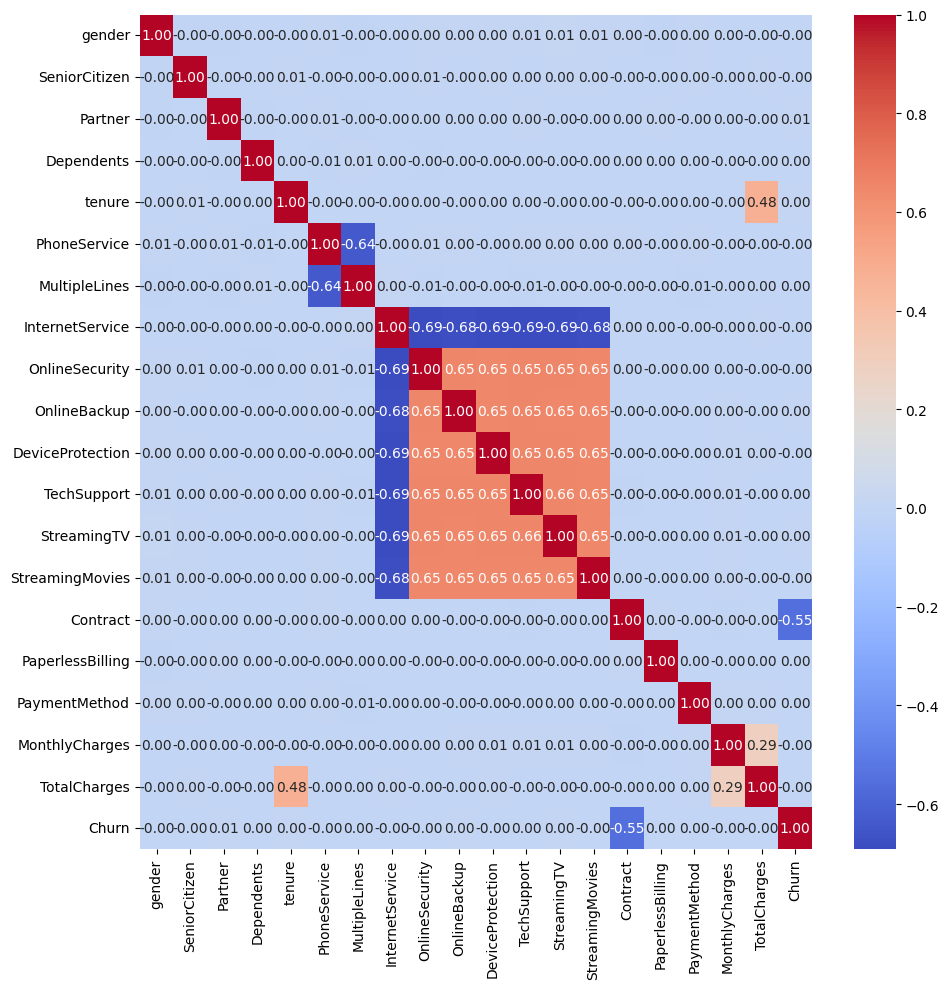

In [87]:
corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,cmap='coolwarm',annot=True,fmt=".2f")
plt.tight_layout()
plt.show()

In [88]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,1,3.0,1,1,0,2,2,2,2,2,2,0,0,0,68.610000,205.83,1
1,0,1,1,0,2.0,1,1,1,0,0,2,1,0,0,1,1,1,23.150000,46.30,0
2,1,0,0,0,42.0,1,1,1,0,1,0,0,1,1,0,0,2,42.630000,1790.46,1
3,1,0,0,1,40.0,1,1,2,0,0,1,0,0,2,0,0,2,75.040000,3001.60,0
4,0,1,1,1,17.0,1,1,2,1,0,1,0,2,0,2,1,2,22.380000,380.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66766,1,0,1,0,1.0,1,1,2,1,1,0,1,1,0,1,1,0,31.000000,31.00,0
66767,1,0,0,0,13.0,1,1,2,0,0,0,0,1,0,2,1,2,52.980000,688.74,1
66768,0,0,1,0,48.0,1,0,2,1,0,0,2,0,1,0,0,1,96.890000,4650.72,1
66769,1,0,0,0,32.0,1,1,1,0,1,2,0,0,2,0,0,2,38.690000,1238.08,0


In [89]:
y = df['Churn']
df = df.drop(columns='Churn')

In [91]:
selected_feature = df[['tenure','Contract','InternetService','OnlineSecurity','TechSupport','MonthlyCharges','TotalCharges','PaperlessBilling','gender','SeniorCitizen','Partner','Dependents']]

In [95]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(selected_feature,y,test_size=0.25,random_state=42)

In [96]:
from sklearn.preprocessing import StandardScaler
scalor = StandardScaler()
x_train_scaled = scalor.fit_transform(x_train)
x_test_scaled = scalor.transform(x_test)

In [97]:
from sklearn.linear_model import LogisticRegression
LReg = LogisticRegression()

In [98]:
LReg.fit(x_train_scaled,y_train)

LogisticRegression()

In [99]:
print("Train Score :",LReg.score(x_train_scaled,y_train))
print("Test Score :",LReg.score(x_test_scaled,y_test))

Train Score : 0.7665441910619434
Test Score : 0.7750554124483316


In [100]:
from sklearn.metrics import roc_auc_score,classification_report
y_pred_proba = LReg.predict_proba(x_test_scaled)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_pred_proba))

Roc_Auc_Score : 0.7927170157670829


In [101]:
y_pred = LReg.predict(x_test_scaled)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      8851
           1       0.70      0.90      0.79      7842

    accuracy                           0.78     16693
   macro avg       0.79      0.78      0.77     16693
weighted avg       0.80      0.78      0.77     16693



In [102]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # supports l1
    'class_weight': [None, 'balanced']
}

In [103]:
Rlr = RandomizedSearchCV(estimator=LReg,param_distributions=param_dist,cv=5,random_state=42,scoring='roc_auc')

In [104]:
Rlr.fit(x_train_scaled,y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100],
                                        'class_weight': [None, 'balanced'],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   random_state=42, scoring='roc_auc')

In [105]:
print(R"Best Parameter :",Rlr.best_params_)

Best Parameter : {'solver': 'liblinear', 'penalty': 'l2', 'class_weight': None, 'C': 100}


In [106]:
print("Train Score :",Rlr.score(x_train_scaled,y_train))
print("Test Score :",Rlr.score(x_test_scaled,y_test))

Train Score : 0.7910157354036419
Test Score : 0.7926592859523552


In [107]:
y_rlr_pred_proba = Rlr.predict_proba(x_test_scaled)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_rlr_pred_proba))

Roc_Auc_Score : 0.7926592859523552


In [108]:
y_rlr_pred = Rlr.predict(x_test_scaled)
print(classification_report(y_test,y_rlr_pred))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      8851
           1       0.70      0.90      0.79      7842

    accuracy                           0.78     16693
   macro avg       0.79      0.78      0.77     16693
weighted avg       0.80      0.78      0.77     16693



In [112]:
model = Rlr

In [132]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(max_depth=5)

In [133]:
rfc.fit(x_train,y_train)

RandomForestClassifier(max_depth=5)

In [134]:
print("Train Score :",rfc.score(x_train,y_train))
print("Test Score :",rfc.score(x_test,y_test))

Train Score : 0.7665242222133472
Test Score : 0.7750554124483316


In [135]:
y_rfc_pred_proba = rfc.predict_proba(x_test)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_rfc_pred_proba))

Roc_Auc_Score : 0.7916403122210488


In [136]:
y_rfc_pred = rfc.predict(x_test)
print(classification_report(y_test,y_rfc_pred))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      8851
           1       0.70      0.90      0.79      7842

    accuracy                           0.78     16693
   macro avg       0.79      0.78      0.77     16693
weighted avg       0.80      0.78      0.77     16693



In [137]:
param_dist_1 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

In [138]:
Rrfc = RandomizedSearchCV(estimator=rfc,param_distributions=param_dist_1,n_iter = 10,n_jobs=-1,cv=3,random_state=42,scoring='roc_auc')

In [139]:
Rrfc.fit(x_train,y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(max_depth=5),
                   n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [5, 10, 15],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 8],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='roc_auc')

In [140]:
print("Best Parameters :",Rrfc.best_params_)

Best Parameters : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': None}


In [141]:
print("Train Score :",Rrfc.score(x_train,y_train))
print("Test Score :",Rrfc.score(x_test,y_test))

Train Score : 0.9313506892427836
Test Score : 0.7925217544296721


In [142]:
y_Rrfc_pred_proba = Rrfc.predict_proba(x_test)[:,1]
print("Roc_Auc_Score :",y_Rrfc_pred_proba)

Roc_Auc_Score : [0.68249941 0.76489964 0.04633994 ... 0.21446615 0.63509884 0.21792721]


In [143]:
y_Rrfc_pred = Rrfc.predict(x_test)
print(classification_report(y_test,y_Rrfc_pred))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      8851
           1       0.70      0.90      0.79      7842

    accuracy                           0.77     16693
   macro avg       0.79      0.78      0.77     16693
weighted avg       0.80      0.77      0.77     16693



In [144]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

In [145]:
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [146]:
print("Trian Score :",xgb.score(x_train,y_train))
print("Test Score :",xgb.score(x_test,y_test))

Trian Score : 0.7840369024322058
Test Score : 0.7694243095908465


In [147]:
y_xgb_pred_proba = xgb.predict_proba(x_test)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_xgb_pred_proba))

Roc_Auc_Score : 0.7923903820025207


In [148]:
y_xgb_pred = xgb.predict(x_test)
print(classification_report(y_xgb_pred,y_test))

              precision    recall  f1-score   support

           0       0.67      0.86      0.76      6942
           1       0.88      0.70      0.78      9751

    accuracy                           0.77     16693
   macro avg       0.78      0.78      0.77     16693
weighted avg       0.79      0.77      0.77     16693



In [149]:
param_dist = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}


In [150]:
Rxg = RandomizedSearchCV(xgb,param_distributions=param_dist,n_iter=20, cv=5,scoring='roc_auc',n_jobs=-1,random_state=42)

In [151]:
Rxg.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8],
                                        'learning_rate': [0.05, 0.1],
                                        'max_depth': [4, 6],
                                        'n_estimators': [200, 300],
                                        'subsample': [0.8]},
                   random_state=42, scoring='roc_auc')

In [152]:
print("Train_Score :",Rxg.score(x_train,y_train))
print("Test_Score :",Rxg.score(x_test,y_test))

Train_Score : 0.8575823786433318
Test_Score : 0.7929612761311694


In [153]:
y_Rxg_pred_proba = Rxg.predict_proba(x_test)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_Rxg_pred_proba))

Roc_Auc_Score : 0.7929612761311694


In [154]:
y_Rxg_pred = Rxg.predict(x_test)
print(classification_report(y_test,y_Rxg_pred))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76      8851
           1       0.71      0.89      0.79      7842

    accuracy                           0.77     16693
   macro avg       0.79      0.78      0.77     16693
weighted avg       0.80      0.77      0.77     16693



### Insight:
The model achieved 90% recall for churn customers, meaning most at-risk customers were successfully identified.
Precision is moderate, indicating some false positives, which is acceptable in churn prevention scenarios.

In [155]:
import pickle
with open("Churn_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66771 entries, 0 to 66770
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            66771 non-null  int64  
 1   SeniorCitizen     66771 non-null  int64  
 2   Partner           66771 non-null  int64  
 3   Dependents        66771 non-null  int64  
 4   tenure            66771 non-null  float64
 5   PhoneService      66771 non-null  int64  
 6   MultipleLines     66771 non-null  int64  
 7   InternetService   66771 non-null  int64  
 8   OnlineSecurity    66771 non-null  int64  
 9   OnlineBackup      66771 non-null  int64  
 10  DeviceProtection  66771 non-null  int64  
 11  TechSupport       66771 non-null  int64  
 12  StreamingTV       66771 non-null  int64  
 13  StreamingMovies   66771 non-null  int64  
 14  Contract          66771 non-null  int64  
 15  PaperlessBilling  66771 non-null  int64  
 16  PaymentMethod     66771 non-null  int64 

In [157]:
for col in df:
    print(f"{col} --> ",df[col].unique())

gender -->  [0 1]
SeniorCitizen -->  [0 1]
Partner -->  [0 1]
Dependents -->  [1 0]
tenure -->  [  3.           2.          42.          40.          17.
  18.          25.          33.           6.          -5.
  22.          10.           8.           5.          47.
  28.          44.          12.         -10.          38.
  21.           4.          16.          29.          51.
  15.           9.          23.          43.          34.
  31.          19.          45.         999.           7.
  65.          14.          30.56973092  13.          32.
  26.          71.          36.          11.          41.
  24.          20.          50.          39.          30.
  48.          46.          27.          52.           1.
  37.          61.          54.          35.          70.
  56.          69.          72.          63.          53.
  68.          57.          58.          62.          66.
  67.          60.          49.          55.          64.
  59.        ]
PhoneService -->  [

In [158]:
import pickle
import numpy as np

# Load model (retrained on selected features)
with open("Churn_model.pkl", "rb") as f:
    model = pickle.load(f)

# Selected feature order
feature_order = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "Contract",
    "PaperlessBilling",
    "MonthlyCharges",
    "TotalCharges"
]

# Sample input
data={
  "gender": 0,
  "SeniorCitizen": 0,
  "Partner": 1,
  "Dependents": 1,
  "tenure": 1,
  "InternetService": 0,
  "OnlineSecurity": 1,
  "TechSupport": 1,
  "Contract": 0,
  "PaperlessBilling": 0,
  "MonthlyCharges": 10,
  "TotalCharges": 10
}

# Arrange features
features = np.array([data[f] for f in feature_order]).reshape(1, -1)

# Prediction
prediction = model.predict(features)[0]
probability = model.predict_proba(features)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", probability)

Prediction: 0
Churn Probability: 0.47146149906166945
